This notebook is directly taken from UMAP's official tutorial ["Better preserving local density using DensMAP"](https://umap-learn.readthedocs.io/en/latest/densmap_demo.html).

# Better Preserving Local Density with DensMAP

A notable assumption in UMAP is that the data is uniformly distributed on some manifold and that it is ultimately this manifold that we would like to present. This is highly effective for many use cases, but it can be the case that one would like to preserve more information about the relative local density of data. A recent paper presented a technique called [DensMAP](https://www.biorxiv.org/content/10.1101/2020.05.12.077776v1) that computes estimates of the local density and uses those estimates as a regularizer in the optimization of the low dimensional representation. The details are well explained in [the paper](https://www.biorxiv.org/content/10.1101/2020.05.12.077776v1) and we encourage those curious about the details to read it. The result is a low dimensional representation that preserves information about the relative local density of the data. To see what this means in practice let’s load some modules and try it out on some familiar data.

In [1]:
import sklearn.datasets
import umap
import umap.plot

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling 

For test data we will make use of the now familiar (see earlier tutorial sections) MNIST and Fashion-MNIST datasets. MNIST is a collection of 70,000 gray-scale images of hand-written digits. Fashion-MNIST is a collection of 70,000 gray-scale images of fashion items.

In [2]:
mnist = sklearn.datasets.fetch_openml("mnist_784")
fmnist = sklearn.datasets.fetch_openml("Fashion-MNIST")

Before we try out DensMAP let’s run standard UMAP so we have a baseline to compare to. We’ll start with MNIST digits.

In [3]:
%%time
mapper = umap.UMAP(random_state=42).fit(mnist.data)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 7min 17s, sys: 632 ms, total: 7min 18s
Wall time: 57.2 s


<Axes: >

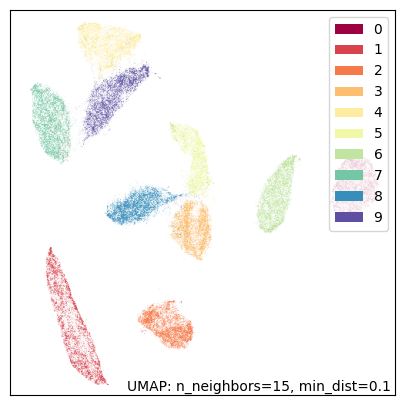

In [4]:
umap.plot.points(mapper, labels=mnist.target, width=500, height=500)

Now let’s try running DensMAP instead. In practice this is as easy as adding the parameter `densmap=True` to the UMAP constructor – this will cause UMAP to use DensMAP regularization with the default DensMAP parameters.

In [5]:
%%time
dens_mapper = umap.UMAP(densmap=True, random_state=42).fit(mnist.data)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 6min 38s, sys: 1.89 s, total: 6min 40s
Wall time: 1min 40s


Note that this is a little slower than standard UMAP – there is a little more work to be done. It is worth noting, however, that the DensMAP overhead is relatively constant, so the difference in runtime won’t increase much as you scale out DensMAP to larger datasets.

Now let’s see what sort of results we get:

<Axes: >

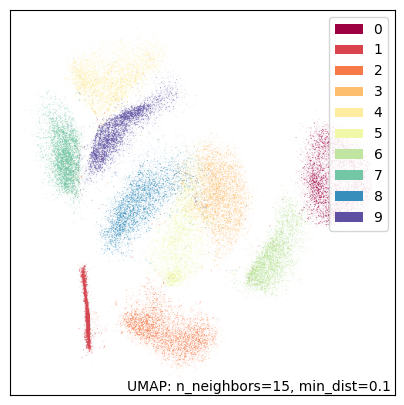

In [6]:
umap.plot.points(dens_mapper, labels=mnist.target, width=500, height=500)

This is a significantly different result – although notably the same groupings of digits and overall structure have resulted. The most striking aspects are that the ones cluster has be compressed into a very narrow and dense stripe, while other digit clusters, most notably the zeros and the twos have expanded out to fill more space in the plot. This is due to the fact that in the high dimensional space the ones are indeed more densely packed together, with largely only variation along one dimension (the angle with which the stroke of the one is drawn). In contrast a digit like the zero has a lot more variation (rounder, narrower, taller, shorter, sloping one way or another); this results in less local density in high dimensional space, and this lack of local density has been preserved by DensMAP.

Let’s now look at the Fashion-MNIST dataset; as before we’ll start by reminding ourselves what the default UMAP results look like:

In [7]:
%%time
mapper = umap.UMAP(random_state=42).fit(fmnist.data)


/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 7min 15s, sys: 701 ms, total: 7min 16s
Wall time: 50.2 s


<Axes: >

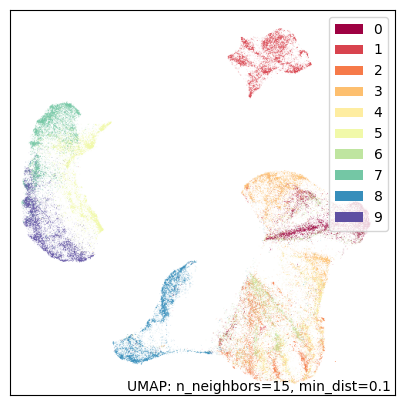

In [8]:
umap.plot.points(mapper, labels=fmnist.target, width=500, height=500)

Now let’s try running DensMAP. As before that is as simple as setting the `densmap=True` flag.

In [9]:
%%time
dens_mapper = umap.UMAP(densmap=True, random_state=42).fit(fmnist.data)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 8min 9s, sys: 675 ms, total: 8min 10s
Wall time: 1min 44s


<Axes: >

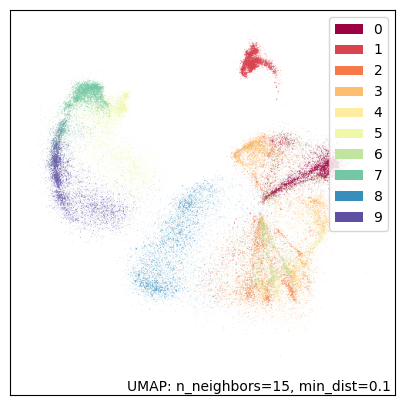

In [10]:
umap.plot.points(dens_mapper, labels=fmnist.target, width=500, height=500)

Again we see that DensMAP provides a plot similar to UMAP broadly, but with striking differences. Here we get to see that the cluster of bags (label 8 in blue) is actually quite sparse, while the cluster of pants (label 1 in red) is actually quite dense with little variation compared to other categories. We even see information internal to clusters. Consider the cluster of boots (label 9 in violet): at the top end it is quite dense, but it fades out into a much sparse region.

So far we have used DensMAP with default parameters, but the implementation provides several parameters for adjusting exactly how the local density regularisation is handled. We encourage readers to consult the paper for the details of the many parameters available. For general use the main parameter of interest is called `dens_lambda` and it controls how strongly the local density regularisation acts. Larger values of `dens_lambda` with make preserving the local density a priority over the the standard UMAP objective, while smaller values lean more towards classical UMAP. The default value is 2.0. Let’s play with it a little so we can see the effects of varying it. To start we’ll use a higher `dens_lambda` of 5.0:

In [11]:
%%time
dens_mapper = umap.UMAP(densmap=True, dens_lambda=5.0, random_state=42).fit(fmnist.data)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 7min 26s, sys: 594 ms, total: 7min 27s
Wall time: 1min 42s


<Axes: >

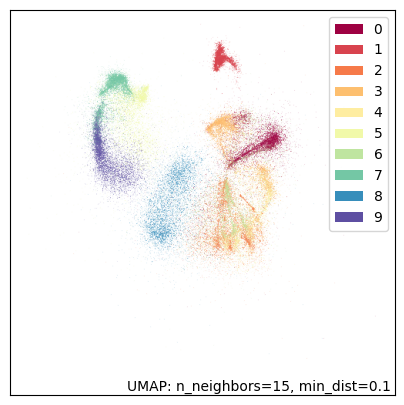

In [12]:
umap.plot.points(dens_mapper, labels=fmnist.target, width=500, height=500)

This looks kind of like what we had before, but blurrier. And also … smaller? The plot bounds are set by the data, so the fact that it is smaller represents the fact that there are some points right out to the edges of the plot. These are likely points that are in locally very sparse regions of the high dimensional space and are thus pushed well away from everything else. We can see this better if we use raw matplotlib and a scatter plot with larger point size:

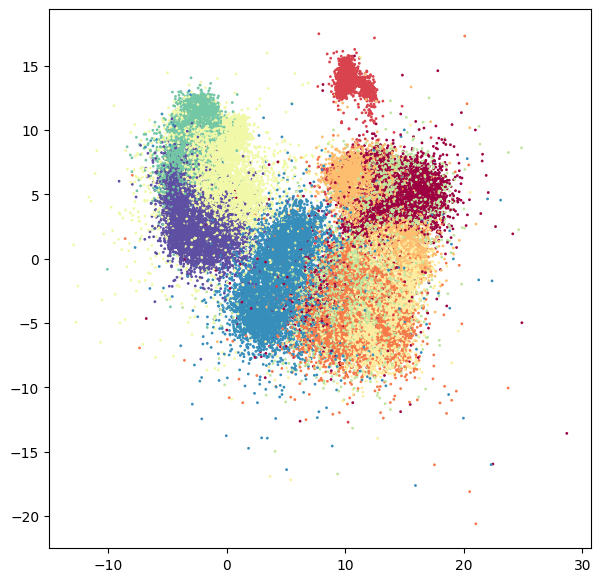

In [13]:
fig, ax = umap.plot.plt.subplots(figsize=(7,7))
ax.scatter(*dens_mapper.embedding_.T, c=fmnist.target.astype('int8'), cmap="Spectral", s=1)

Aside from seeing the issues with overplotting we can see that there are, in fact, quite a few points that create a very soft halo of of sparse points around the fringes.

Now let’s try going the other way and reduce `dens_lambda` to a small value, so that in principle we can recover something quite close to the default UMAP plot, with just a hint of local density information encoded.

In [14]:
%%time
dens_mapper = umap.UMAP(densmap=True, dens_lambda=0.1, random_state=42).fit(fmnist.data)

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 7min 39s, sys: 445 ms, total: 7min 40s
Wall time: 1min 42s


<Axes: >

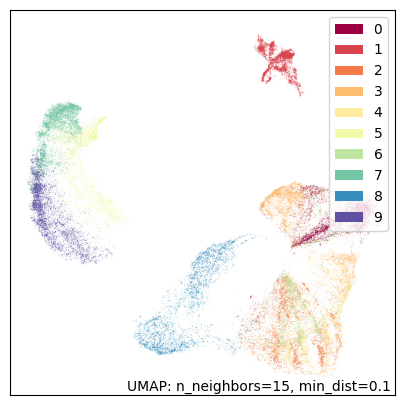

In [15]:
umap.plot.points(dens_mapper, labels=fmnist.target, width=500, height=500)

And indeed, this looks very much like the original plot, but the bags (label 8 in blue) are slightly more diffused, and the pants (label 1 in red) are a little denser. This is very much the default UMAP with just a tweak to better reflect some notion of local density.

## Supervised DensMAP on the Galaxy10SDSS dataset

The [Galaxy10SDSS dataset](https://astronn.readthedocs.io/en/latest/galaxy10sdss.html) is a crowd sourced human labelled dataset of galaxy images, which have been separated in to ten classes. DensMAP can learn an embedding that partially separates the data. To keep runtime small, DensMAP is applied to a subset of the data.

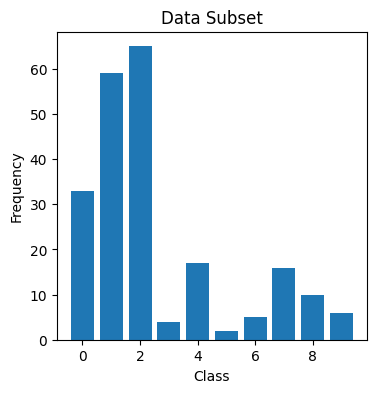

In [16]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import umap
import os
import math
import requests

if not os.path.isfile("Galaxy10.h5"):
    url = "http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5"
    r = requests.get(url, allow_redirects=True)
    open("Galaxy10.h5", "wb").write(r.content)

# To get the images and labels from file
with h5py.File("Galaxy10.h5", "r") as F:
    images = np.array(F["images"])
    labels = np.array(F["ans"])

X_train = np.empty([math.floor(len(labels) / 100), 14283], dtype=np.float64)
y_train = np.empty([math.floor(len(labels) / 100)], dtype=np.float64)
X_test = X_train
y_test = y_train
# Get a subset of the data
for i in range(math.floor(len(labels) / 100)):
    X_train[i, :] = np.array(np.ndarray.flatten(images[i, :, :, :]), dtype=np.float64)
    y_train[i] = labels[i]
    X_test[i, :] = np.array(
        np.ndarray.flatten(images[i + math.floor(len(labels) / 100), :, :, :]),
        dtype=np.float64,
    )
    y_test[i] = labels[i + math.floor(len(labels) / 100)]

# Plot distribution
classes, frequency = np.unique(y_train, return_counts=True)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.bar(classes, frequency)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Data Subset")
plt.savefig("galaxy10_subset.svg")

The figure shows that the selected subset of the data set is unbalanced, but the entire dataset is also unbalanced, so this experiment will still use this subset. The next step is to examine the output of the standard DensMAP algorithm.

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


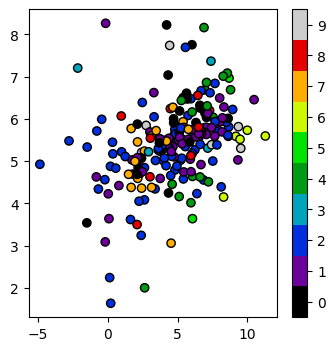

In [17]:
reducer = umap.UMAP(
    densmap=True, n_components=2, random_state=42, verbose=False
)
reducer.fit(X_train)

galaxy10_densmap = reducer.transform(X_train)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_densmap[:, 0],
    galaxy10_densmap[:, 1],
    c=y_train,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_train,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_densmap.svg")

The standard DensMAP algorithm does not separate the galaxies according to their type. Supervised DensMAP can do better.

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


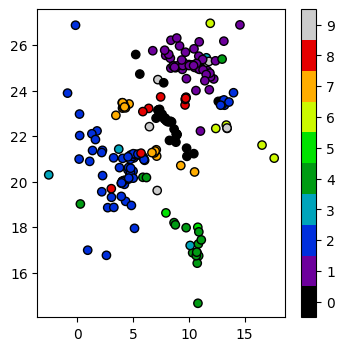

In [18]:
reducer = umap.UMAP(
    densmap=True, n_components=2, random_state=42, verbose=False
)
reducer.fit(X_train, y_train)

galaxy10_densmap_supervised = reducer.transform(X_train)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_densmap_supervised[:, 0],
    galaxy10_densmap_supervised[:, 1],
    c=y_train,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_train,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_densmap_supervised.svg")

Supervised DensMAP does indeed do better. There is a litle overlap between some of the classes, but the original dataset also has some ambiguities in the classification. The best check of this method is to project the testing data onto the learned embedding.

/home/dbissuel/Documents/softs/sourcecodes/PyEMMA/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


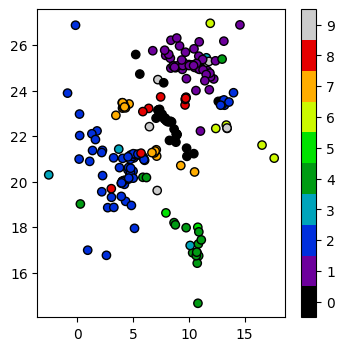

In [19]:
galaxy10_densmap_supervised_prediction = reducer.transform(X_test)
fig = plt.figure(1, figsize=(4, 4))
plt.clf()
plt.scatter(
    galaxy10_densmap_supervised_prediction[:, 0],
    galaxy10_densmap_supervised_prediction[:, 1],
    c=y_test,
    cmap=plt.cm.nipy_spectral,
    edgecolor="k",
    label=y_test,
)
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))
plt.savefig("galaxy10_2D_densmap_supervised_prediction.svg")

This shows that the learned embedding can be used on new data sets, and so this method may be helpful for examining images of galaxies. Try out this method on the full 200 Mb dataset as well as the newer 2.54 Gb [Galaxy 10 DECals dataset](https://astronn.readthedocs.io/en/latest/galaxy10.html)

© Copyright 2018, Leland McInnes.